# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [2]:
# Write your code here.
requests = pd.read_csv('data/nyc_311_street_conditions_2025.csv', parse_dates=['created_date'])


### Preview the data

Display the first and last five rows.


In [3]:
# Write your code here.
print(requests.head())
print(requests.tail())

   request_id        created_date   borough                     descriptor
0    63575321 2025-01-01 02:27:33  BROOKLYN                        Pothole
1    63585580 2025-01-01 02:31:08    QUEENS                        Pothole
2    63590681 2025-01-01 02:39:44  BROOKLYN  Dumpster - Construction Waste
3    63580421 2025-01-01 02:55:52    QUEENS                        Pothole
4    63605103 2025-01-01 04:20:00  BROOKLYN                    Wear & Tear
       request_id        created_date        borough          descriptor
70193    67353473 2025-12-31 22:26:49  STATEN ISLAND             Pothole
70194    67346881 2025-12-31 22:27:34  STATEN ISLAND             Pothole
70195    67352385 2025-12-31 22:28:43  STATEN ISLAND             Cave-in
70196    67350032 2025-12-31 22:53:19      MANHATTAN  Defective Hardware
70197    67348685 2025-12-31 23:39:14         QUEENS             Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [4]:
# Write your code here.
requests.info()

<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.4 MB


**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | Categorical | integer | none |
| `created_date` | Quantitative | datetime | none |
| `borough` | Categorical | string | none |
| `descriptor` | Categorical | string | none |


**What does one row represent?**

Your answer: Each row represents a service request about a street condition.

### Predict


In [5]:
requests.borough.value_counts()

borough
QUEENS           25981
BROOKLYN         18376
MANHATTAN        12387
BRONX             6957
STATEN ISLAND     6497
Name: count, dtype: int64

**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer:My guess based on each specific borough would be Queens. At a glance, looking at the amount of requests that come in give me an idea of how many requests come in. Though this could be a misdirection where there are more people caring (reporting bias).


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [6]:
# Write your code here.
requests['borough'] = requests['borough'].str.title()

**What roles do `.str` and `.title()` play in this statement?**

Your answer: `.str` says for the string values... `.title()` says to make the each string a title (capitalize first letter of each word and lower the rest)


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [7]:
# Write your code here.
requests['date'] = requests['created_date'].dt.normalize()
print(requests['created_date'])
requests['date']


0       2025-01-01 02:27:33
1       2025-01-01 02:31:08
2       2025-01-01 02:39:44
3       2025-01-01 02:55:52
4       2025-01-01 04:20:00
                ...        
70193   2025-12-31 22:26:49
70194   2025-12-31 22:27:34
70195   2025-12-31 22:28:43
70196   2025-12-31 22:53:19
70197   2025-12-31 23:39:14
Name: created_date, Length: 70198, dtype: datetime64[us]


0       2025-01-01
1       2025-01-01
2       2025-01-01
3       2025-01-01
4       2025-01-01
           ...    
70193   2025-12-31
70194   2025-12-31
70195   2025-12-31
70196   2025-12-31
70197   2025-12-31
Name: date, Length: 70198, dtype: datetime64[us]

### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [8]:
# Write your code here.

daily_requests = requests.groupby(by=["date","borough"]).size().reset_index(name = "request_count")

daily_requests.head()


,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of `daily requests` represents the sum total of requests of a given day at a specific borough.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: Grouping together the dates by minute, second, hour, would create too many sub groups. we would want to separate less granularly. Just by the date would be fine. Another grouping that could show some insight would be month, or with a bit more data finagling we could get it by quarter or season!


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [9]:
# Write your code here.
borough_order = requests.borough.value_counts().sort_index().index.tolist()
borough_order

['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [10]:
# Write your code here.
borough_summary = daily_requests.groupby('borough')['request_count'].mean().reindex(borough_order)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer:Comparing only the average count of requests made per day is incomplete because it does not define what are common requests.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [11]:
# Write your code here.
daily_requests.groupby('borough').count().reindex(borough_order)

,date,request_count
borough,,
Bronx,365,365
Brooklyn,365,365
Manhattan,365,365
Queens,365,365
Staten Island,365,365


**Does every borough have a count for all 365 dates?**

Your answer:Yes


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer:There was a day where in that borough no requests were made.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [12]:
# Write your code here.
print('date:\t\t',daily_requests['date'].isna().sum())
print('borough:\t',daily_requests['borough'].isna().sum())
print('request_count:\t',daily_requests['request_count'].isna().sum())

daily_requests.groupby('borough')['request_count'].describe().reindex(borough_order)

date:		 0
borough:	 0
request_count:	 0


,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No calculated values are missing or impossible. It is worth mentioning however that Queens has an unusually high maximum of 215. Which could be due to weather or a major event.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: A zero would not necessarily be impossible. There can be days where there are no requests made though not likely, it is still probable

## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


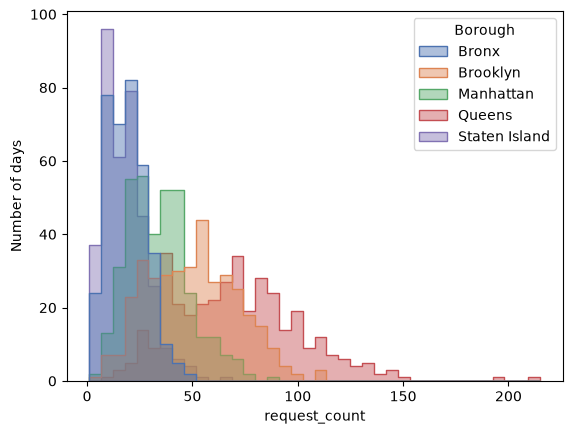

In [13]:
# Write your code here.
ax = sns.histplot(
    data = daily_requests,
    x = 'request_count',
    hue='borough',
    hue_order=borough_order,
    element='step',
    alpha=0.45,
    palette='deep',
    )

ax.legend_.set_title('Borough')
ax.set_ylabel('Number of days')
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram reveals the average amount of requests per day. Queens shows that there are outliers that appear in the 200's (which explains the maximum being 215). Bronx and Staten Island show to have the lowest average amount of requests made per day in the span of a year. 

This graph makes being able to compare similarities in boroughs as well as highlight the outliers.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


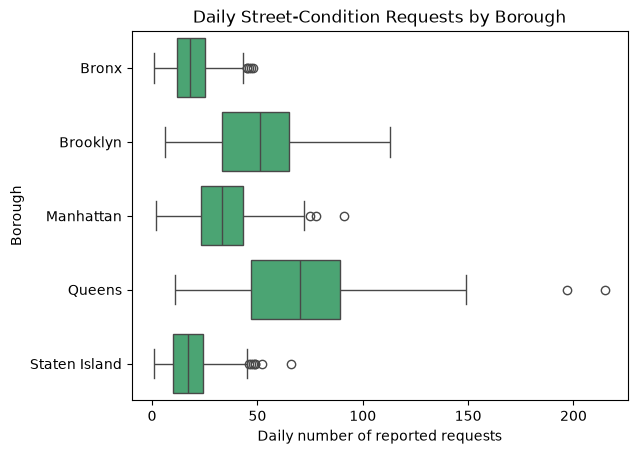

In [14]:
# Write your code here.
sns.boxplot(
    data = daily_requests,
    x = 'request_count',
    y = 'borough',
    hue_order = borough_order,
    color='mediumseagreen'
    )

plt.xlabel("Daily number of reported requests")
plt.ylabel('Borough')
plt.title('Daily Street-Condition Requests by Borough')
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The histogram was extremely cluttered and difficult to read. The box plot is better for this case when observing distributions because we can see the five number summary along with outliers.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


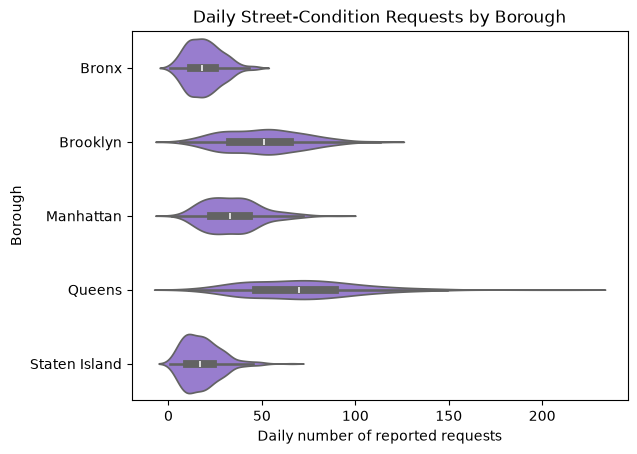

In [15]:
# Write your code here.
sns.violinplot(
    data = daily_requests,
    x = 'request_count',
    y = 'borough',
    hue_order = borough_order,
    color='mediumpurple'
    )

plt.xlabel("Daily number of reported requests")
plt.ylabel('Borough')
plt.title('Daily Street-Condition Requests by Borough')
plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot adds the distribution of the data. The width of each of the plots expose the density of each borough's distribution.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: I would picke the violin plot to compare daily request counts among the boroughs. The width shows where values are most common, and the inner box shows the median and middle 50% of the data. With the violin plot, it becomes easier to compare the boroughs' counts, spread, and distribution shapes.

## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Queens has the most varying distribution where they could range from 11 daily requests to 215. Along with that, Staten Island and the Bronx show a fall beween the lower requested boroughs and Queens in their typical daily count requests. 


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The limitation of this data set does not measure the number of street problems or borough performance because some problems may never be reported or one problem may be reported multiple times. Each Boroughs differ in population size which could skew the reporting habits.

# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the daily number of reported street-condition requests vary across street-condition descriptors and days of the week in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use the original created_date feature to create a categorical day_of_week feature. Each row of my calculated DataFrame will represent one calendar date and contain its day of the week and the total number of requests reported that day.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [16]:
# Write your code here.
# Create the column that categorizes the date
requests['day_of_week'] = requests['date'].dt.day_name()

# next group count the descriptor and day of week together 
descriptor_weekday_counts = (
    requests.groupby(['descriptor','day_of_week']).size().reset_index(name='request_count')
)

# descriptor_weekday_counts

daily_descriptor_requests = (
    requests.groupby(['date','descriptor','day_of_week'])
    .size()
    .reset_index(name='request_count')
)

daily_descriptor_requests

,date,descriptor,day_of_week,request_count
0,2025-01-01,Blocked - Construction,Wednesday,2
1,2025-01-01,Cave-in,Wednesday,9
2,2025-01-01,Defective Hardware,Wednesday,7
3,2025-01-01,Dumpster - Construction Waste,Wednesday,2
4,2025-01-01,Failed Street Repair,Wednesday,4
...,...,...,...,...
4109,2025-12-31,Plate Condition - Noisy,Wednesday,2
4110,2025-12-31,Plate Condition - Open,Wednesday,1
4111,2025-12-31,Plate Condition - Shifted,Wednesday,6
4112,2025-12-31,Pothole,Wednesday,84


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer:I created the categorical day_of_week feature from the date column using .dt.day_name(). Then I grouped the requests by date, descriptor, and day_of_week. The .size() method counted the requests in each group, and .reset_index(name='request_count') stored those counts as the quantitative feature request_count. Each row represents one date–descriptor combination and its number of requests.

## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [17]:
# Write your code here.
# Check for missing values
print(daily_descriptor_requests[
    ["date", "descriptor", "day_of_week", "request_count"]
].isna().sum())

# Check for impossible request counts
print("Non-positive counts:",
      (daily_descriptor_requests["request_count"] <= 0).sum())

# Confirm all weekday groups are present
expected_days = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

print("Weekdays present:",
      sorted(daily_descriptor_requests["day_of_week"].unique()))

print("Missing weekdays:",
      sorted(set(expected_days) -
            set(daily_descriptor_requests["day_of_week"].unique())))

# Summarize request-count distributions
daily_descriptor_requests.groupby(
    ["descriptor", "day_of_week"]
)["request_count"].describe()

date             0
descriptor       0
day_of_week      0
request_count    0
dtype: int64
Non-positive counts: 0
Weekdays present: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Missing weekdays: []


count       mean       std  min   25%  \
descriptor             day_of_week                                          
Blocked - Construction Friday        52.0  13.673077  5.223331  3.0  10.0   
                       Monday        52.0  13.038462  5.091175  3.0   9.0   
                       Saturday      52.0   5.942308  2.703763  1.0   4.0   
                       Sunday        50.0   4.360000  2.135798  1.0   3.0   
                       Thursday      52.0  14.807692  6.271749  2.0  10.0   
...                                   ...        ...       ...  ...   ...   
Wear & Tear            Saturday       8.0   1.375000  0.744024  1.0   1.0   
                       Sunday        14.0   1.428571  0.646206  1.0   1.0   
                       Thursday      17.0   3.058824  2.925547  1.0   1.0   
                       Tuesday       23.0   2.652174  4.107739  1.0   1.0   
                       Wednesday     24.0   3.166667  3.874854  1.0   1.0   

                                     50%    75%   max  
descriptor             day_of_week                     
Blocked - Construction Friday       12.0  17.25  25.0  
                       Monday       14.0  17.00  22.0  
                       Saturday      6.0   8.00  15.0  
                       Sunday        4.0   5.00  12.0  
                       Thursday     14.0  19.00  29.0  
...                                  ...    ...   ...  
Wear & Tear            Saturday      1.0   1.25   3.0  
                       Sunday        1.0   2.00   3.0  
                       Thursday      2.0   4.00  12.0  
                       Tuesday       2.0   3.00  21.0  
                       Wednesday     1.5   3.25  17.0  

[135 rows x 8 columns]

**What did your checks establish?**

Your answer:The checks established that the calculated DataFrame contains no missing values and no impossible request counts. All seven days of the week are represented, and every request count is positive. The numerical summary also showed how daily request counts vary across the descriptor and day-of-week groups.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


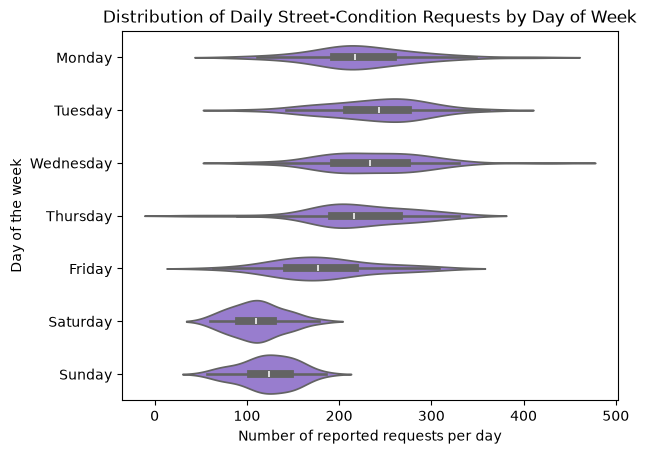

In [18]:
# Write your code here.
daily_weekday_requests = (
    daily_descriptor_requests
    .groupby(["date", "day_of_week"])["request_count"]
    .sum()
    .reset_index()
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sns.violinplot(
    data=daily_weekday_requests,
    x="request_count",
    y="day_of_week",
    order=day_order,
    color="mediumpurple"
)

plt.title("Distribution of Daily Street-Condition Requests by Day of Week")
plt.xlabel("Number of reported requests per day")
plt.ylabel("Day of the week")
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer:The strongest evidence is that weekday violins are centered at much higher request counts than the weekend violins. Saturday and Sunday have the lowest typical daily counts, while Tuesday and Wednesday are among the highest. This suggests that reported street-condition requests were generally more common during the week than on weekends.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer:In 2025, the typical number of reported street-condition requests was higher on weekdays than on weekends. Tuesday and Wednesday had some of the highest typical daily counts, while Saturday and Sunday had the lowest.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer:This shows a difference in reported request volume by day of the week, but it does not prove that the actual number of street problems changes by weekday.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer:I used an AI tool to clarify the lab instructions and review my code and interpretations. One suggestion was to group the requests by date and day_of_week before calculating the daily request count. I checked the code against the assignment requirements and accepted the suggestion because it produced one row per date with the number of requests for that day.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
